In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/falkodz/TER.git /content/TER
!pip install transformers emoji==0.6.0 -q

import os, shutil
os.makedirs('/content/TER/data', exist_ok=True)
shutil.copy('/content/drive/MyDrive/Colab Notebooks/ChatGPT_final.csv',
            '/content/TER/data/ChatGPT_final.csv')
print("Done ✓")


Mounted at /content/drive
Cloning into '/content/TER'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 84 (delta 39), reused 62 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 4.63 MiB | 24.56 MiB/s, done.
Resolving deltas: 100% (39/39), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Done ✓


In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/TER/data/ChatGPT_final.csv',
                 usecols=['Tweet', 'cleaned_tweet', 'sentiment'],
                 low_memory=False)

df = df.dropna(subset=['Tweet', 'cleaned_tweet', 'sentiment'])
df = df[df['cleaned_tweet'].str.strip() != '']

label2id = {'positive': 0, 'neutral': 1, 'negative': 2}
df['label'] = df['sentiment'].map(label2id)

# Split
train_df, test_df = train_test_split(df, test_size=0.15, random_state=42, stratify=df['label'])

tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=3)
X_train = tfidf.fit_transform(train_df['cleaned_tweet'])
X_test = tfidf.transform(test_df['cleaned_tweet'])

# LinearSVC
svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm.fit(X_train, train_df['label'])
test_df = test_df.copy()
test_df['predicted'] = svm.predict(X_test)
test_df['predicted_label'] = test_df['predicted'].map({0:'positive', 1:'neutral', 2:'negative'})
test_df['correct'] = test_df['label'] == test_df['predicted']

print(f"Test size: {len(test_df)}")
print(f"Accuracy: {test_df['correct'].mean():.3f}")
print(classification_report(test_df['label'], test_df['predicted'],
      target_names=['positive', 'neutral', 'negative']))

Test size: 71429
Accuracy: 0.867
              precision    recall  f1-score   support

    positive       0.92      0.88      0.90     37497
     neutral       0.85      0.89      0.87     22639
    negative       0.73      0.76      0.75     11293

    accuracy                           0.87     71429
   macro avg       0.84      0.85      0.84     71429
weighted avg       0.87      0.87      0.87     71429



Total errors: 9532 (13.3%)

Error breakdown:
  sentiment predicted_label  count
5  positive         neutral   2284
4  positive        negative   2141
1  negative        positive   1505
3   neutral        positive   1432
0  negative         neutral   1174
2   neutral        negative    996


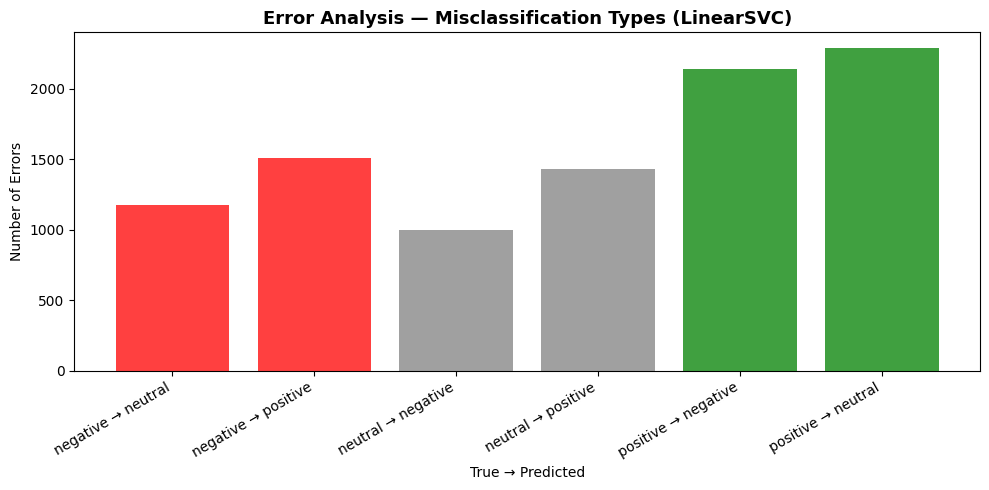


=== EXAMPLES OF MISCLASSIFIED TWEETS ===

--- True: POSITIVE → Predicted: NEUTRAL ---
  • One day after Microsoft announced its new Edge browser, which includes a ChatGPT experience powered by OpenAI, Bing rock...
  • #ChatGPT Well, the future is here: https://t.co/jhFBNPS9BE...

--- True: POSITIVE → Predicted: NEGATIVE ---
  • Google search chief warns AI chatbots can give 'convincing but completely fictitious' answers, report says https://t.co/...
  • "[submissions] also passed another critical test: a screening by Turnitin, a popular anti-plagiarism software"

https://...

--- True: NEUTRAL → Predicted: POSITIVE ---
  • Pretend to be a fictious lawyer for Emperor Palpatine and write  a defense plea for Palpatine 's actions. #StarWars #Cha...
  • the good in #chatgpt up to now is the focus it has put on the process of #writing, the bad being the same default that t...

--- True: NEUTRAL → Predicted: NEGATIVE ---
  • #Fake #ChatGPT #Chrome #Browser #Extension #Caught Hijacking Facebo

In [3]:
# Isoler les erreurs
errors = test_df[~test_df['correct']].copy()
print(f"Total errors: {len(errors)} ({len(errors)/len(test_df)*100:.1f}%)")
print(f"\nError breakdown:")
print(errors.groupby(['sentiment', 'predicted_label']).size().reset_index(name='count').sort_values('count', ascending=False))

# Visualisation confusion des erreurs
error_types = errors.groupby(['sentiment', 'predicted_label']).size().reset_index(name='count')
error_types = error_types[error_types['sentiment'] != error_types['predicted_label']]

plt.figure(figsize=(10, 5))
colors = {'positive': 'green', 'neutral': 'gray', 'negative': 'red'}
bars = plt.bar(
    [f"{r['sentiment']} → {r['predicted_label']}" for _, r in error_types.iterrows()],
    error_types['count'],
    color=[colors[r['sentiment']] for _, r in error_types.iterrows()],
    alpha=0.75
)
plt.title('Error Analysis — Misclassification Types (LinearSVC)', fontsize=13, fontweight='bold')
plt.xlabel('True → Predicted')
plt.ylabel('Number of Errors')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/content/TER/figures/15_error_analysis.png', dpi=150)
plt.show()

# Exemples de tweets mal classés
print("\n=== EXAMPLES OF MISCLASSIFIED TWEETS ===")
for true_label in ['positive', 'neutral', 'negative']:
    for pred_label in ['positive', 'neutral', 'negative']:
        if true_label != pred_label:
            sample = errors[(errors['sentiment'] == true_label) &
                          (errors['predicted_label'] == pred_label)].head(2)
            if len(sample) > 0:
                print(f"\n--- True: {true_label.upper()} → Predicted: {pred_label.upper()} ---")
                for _, row in sample.iterrows():
                    print(f"  • {row['Tweet'][:120]}...")

In [4]:
import subprocess, shutil, os, re
from getpass import getpass

# Sauvegarder la figure
os.makedirs('/content/TER/figures', exist_ok=True)

# Nettoyer et copier le notebook
with open('/content/drive/MyDrive/Colab Notebooks/10_error_analysis.ipynb', 'r') as f:
    content = f.read()
content_clean = re.sub(r'ghp_[a-zA-Z0-9]+', 'TOKEN_REMOVED', content)
with open('/content/TER/notebooks/10_error_analysis.ipynb', 'w') as f:
    f.write(content_clean)

subprocess.run(['git', 'add', '.'], cwd='/content/TER')
r = subprocess.run(['git', 'commit', '-m', 'Add error analysis notebook + figure'],
                   cwd='/content/TER', capture_output=True, text=True)
print(r.stdout, r.stderr)

token = getpass("Token : ")
result = subprocess.run(
    ['git', 'push', f'https://{token}@github.com/falkodz/TER.git', 'main'],
    cwd='/content/TER', capture_output=True, text=True
)
print(result.stdout, result.stderr)

 Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@8a3cef2029d1.(none)')

Token : ··········
 Everything up-to-date



In [5]:
import os
for f in os.listdir('/content/drive/MyDrive/Colab Notebooks/'):
    print(f)

ChatGPT_final.csv
Copie de 05_temporal_analysis (1).ipynb
04_baseline_model.ipynb
05_temporal_analysis.ipynb
Copie de 05_temporal_analysis.ipynb
Copie de 06_bertweet_finetuning.ipynb
06_bertweet_finetuning.ipynb
Copie de 08_lda_topic_modeling.ipynb
Copie de 07_walkforward_evaluation.ipynb
Copie de 09_bertweet_walkforward (1).ipynb
09_bertweet_walkforward.ipynb
Copie de 09_bertweet_walkforward.ipynb
10_error_analysis.ipynb
Copie de 10_error_analysis.ipynb
